# Smart Dirt Buildup Detection for Conveyor Belt Systems

**Authors:** Erick Chauke, Dr Milka Madahana, & Dr John Ekoru  
**Dataset:** [IEEE DataPort](https://ieee-dataport.org/open-access/dirt-buildup-belt-conveyor-structures)

---

## Introduction

Mining operations rely on long conveyor belt systems to transport ore across distances. Over time, dirt and material from the ore accumulates on the belt structures, specifically on rollers and frames. When this buildup goes undetected, rollers seize up, belts drift sideways, and in serious cases fires start. A single unplanned stoppage costs a mine tens of thousands of dollars per hour.

This notebook addresses that problem by training a model to classify images of conveyor belt structures as either clean or carrying dirt buildup. The dataset contains 388 labelled photographs sourced from a real mining environment.

The approach taken in this notebook:

- Exploring and understanding the dataset before building anything
- Splitting data correctly to prevent leakage, then applying preprocessing and augmentation
- Establishing a scratch-built baseline model
- Training and fine-tuning two pretrained models, ResNet-50 and EfficientNet-B0
- Evaluating all models against the benchmark set by Santos et al. (2020), who achieved 89.75% accuracy and an F1-score of 0.8773 on a similar task
- Interpreting model decisions using Grad-CAM heatmaps and analysing failure cases


### Loading Libraries

In [2]:
# Install required libraries quietly
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["timm", "albumentations", "scikit-learn", "matplotlib", "seaborn"]:
    install(pkg)

# Core libraries
import random                                    # random number generation
import numpy as np                               # numerical operations
import torch                                     # neural network framework
import timm                                      # pretrained model library
import albumentations as A                       # image augmentation
import matplotlib.pyplot as plt                  # plotting and visualisation
import seaborn as sns                            # statistical charts
from sklearn.model_selection import train_test_split  # dataset splitting


SEED = 42  # any fixed number works, 42 is a common convention in data science

# Fix all random sources so every run produces the same results
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


### Dataset Inspection

This section reads the images already saved in the data folder, counts the number
in each class, and displays a sample grid from both groups side by side. The goal
is to understand what the data looks like before any processing takes place.


Clean images : 227
Dirty images : 161
Total        : 388


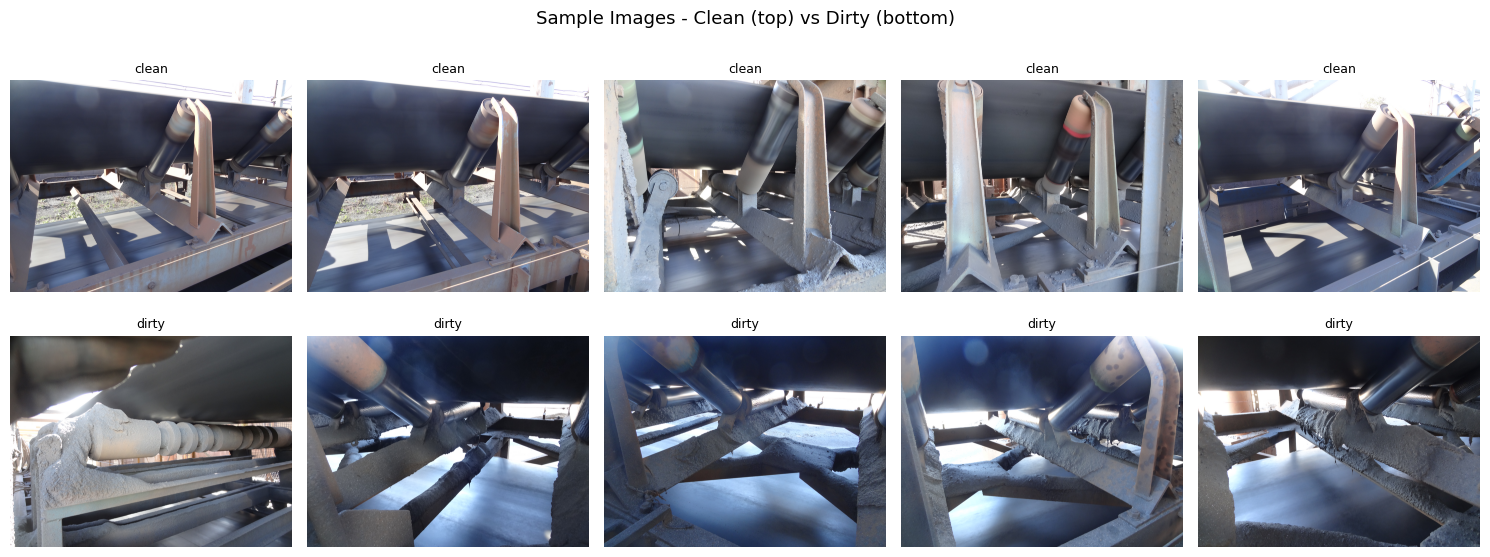

In [3]:
import os
from pathlib import Path
from PIL import Image  # image loading

# Point to the dataset folders
DATA_DIR = Path("data")
CLASSES = ["clean", "dirty"]

# Count images per class
counts = {cls: len(list((DATA_DIR / cls).glob("*"))) for cls in CLASSES}
total = sum(counts.values())

print(f"Clean images : {counts['clean']}")
print(f"Dirty images : {counts['dirty']}")
print(f"Total        : {total}")

# Display a 2x5 sample grid, 5 images per class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Images - Clean (top) vs Dirty (bottom)", fontsize=13)

for row, cls in enumerate(CLASSES):
    image_paths = list((DATA_DIR / cls).glob("*"))[:5]
    for col, path in enumerate(image_paths):
        img = Image.open(path).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        axes[row, col].set_title(cls, fontsize=9)

plt.tight_layout()
plt.show()


### Exploratory Data Analysis

Before building any model, this section asks questions of the data.

- Are there roughly equal numbers of clean and dirty images? If one class has far
  more images than the other, the model may learn to favour it and perform poorly
  on the smaller class.
- Is the brightness consistent across photos? Mine environments vary heavily, some
  shots are bright outdoor scenes, others are nearly dark underground. If dirty images
  happen to be darker on average, the model might learn to detect darkness rather
  than dirt.
- What visually separates a clean belt structure from a dirty one?

The answers here shape every decision that follows.


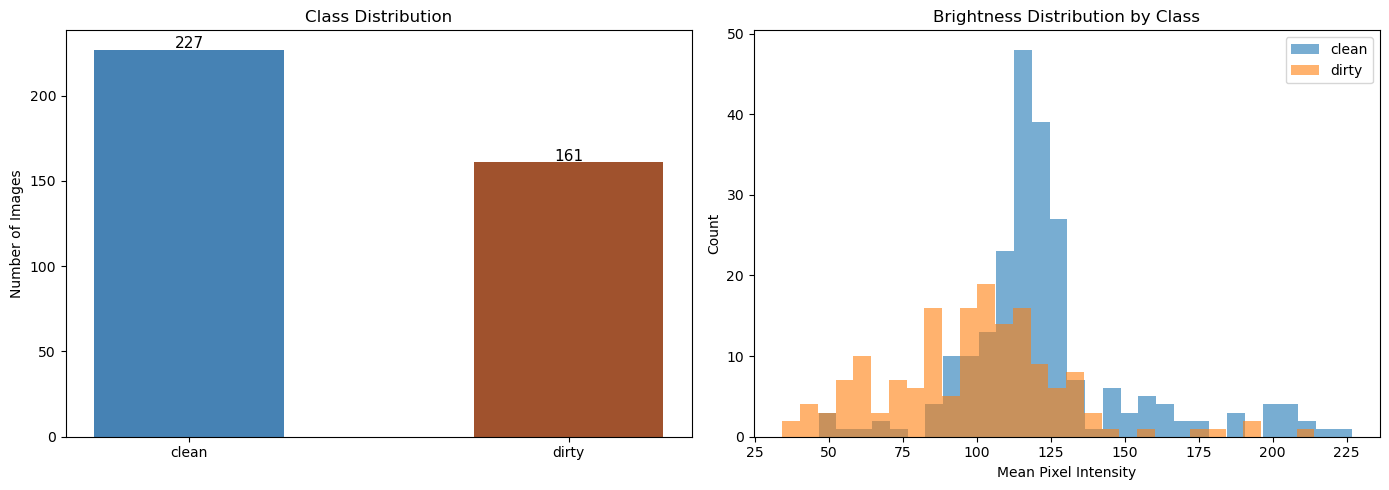

In [4]:
import cv2  # image reading for pixel-level analysis

# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(counts.keys(), counts.values(), color=["steelblue", "sienna"], width=0.5)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Number of Images")
for i, (cls, count) in enumerate(counts.items()):
    axes[0].text(i, count + 1, str(count), ha="center", fontsize=11)

# Brightness distribution per class
for cls in CLASSES:
    brightness_vals = []
    for path in (DATA_DIR / cls).glob("*"):
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            brightness_vals.append(img.mean())
    axes[1].hist(brightness_vals, bins=30, alpha=0.6, label=cls)

axes[1].set_title("Brightness Distribution by Class")
axes[1].set_xlabel("Mean Pixel Intensity")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


### Splitting the Dataset

The 388 images are divided into three non-overlapping groups:

- **Training set (~270 images)** - what the model learns from
- **Validation set (~70 images)** - used to monitor progress during training
- **Test set (~48 images)** - the final exam, never seen during training

Each group is split so it contains the same proportion of clean to dirty images as
the full dataset (this is called stratified splitting).

One rule governs this section: split before touching anything. No resizing, no
brightness correction, nothing happens before this step. Modifying images first and
splitting after causes data leakage, where information from the test set quietly
influences training and makes the final results look better than they really are.


In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Collect all image paths and their labels
all_paths = []
all_labels = []

for cls in CLASSES:
    for path in (DATA_DIR / cls).glob("*"):
        all_paths.append(str(path))
        all_labels.append(cls)

# First split: carve out the test set (12.5% of total ~ 48 images)
# stratify ensures both classes are proportionally represented in every split
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.125,
    stratify=all_labels,
    random_state=SEED
)

# Second split: carve out validation from the remainder (~20% of remainder ~ 70 images)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.20,
    stratify=train_val_labels,
    random_state=SEED
)

print(f"Training   : {len(train_paths)} images")
print(f"Validation : {len(val_paths)} images")
print(f"Test       : {len(test_paths)} images")

# Save splits to CSV so they can be reloaded later without re-splitting
splits_df = pd.DataFrame({
    "path": train_paths + val_paths + test_paths,
    "label": train_labels + val_labels + test_labels,
    "split": ["train"] * len(train_paths) + ["val"] * len(val_paths) + ["test"] * len(test_paths)
})

splits_df.to_csv("data/splits.csv", index=False)
print("\nSplits saved to data/splits.csv")


Training   : 271 images
Validation : 68 images
Test       : 49 images

Splits saved to data/splits.csv


### Preprocessing

The model expects images at exactly 224x224 pixels, so every image is resized to
that size. A brightness correction step is also applied because mine photos vary
heavily in lighting conditions. Without it, the model risks learning to distinguish
lighting rather than dirt.

Finally, pixel values are scaled to the numerical range the pretrained model was
originally trained on (this is called **normalisation** and uses the <u>mean</u> and <u>standard deviation</u> values from the ImageNet dataset, which is what the pretrained models in this project were trained on).

All three steps apply to all three splits equally.

In [6]:
from albumentations.pytorch import ToTensorV2

# ImageNet mean and std - required because pretrained models were trained on these values
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Preprocessing applied to all three splits - resize, brightness correction, normalise
base_transform = A.Compose([
    A.Resize(224, 224),                         # pretrained models expect 224x224
    A.CLAHE(clip_limit=2.0, p=1.0),             # corrects uneven lighting across photos
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # scale pixels to ImageNet range
    ToTensorV2()                                # convert to PyTorch tensor
])

print("Preprocessing pipeline defined")
print(f"  Resize       : 224x224")
print(f"  CLAHE        : clip_limit=2.0 (brightness correction)")
print(f"  Normalise    : ImageNet mean={IMAGENET_MEAN}, std={IMAGENET_STD}")


Preprocessing pipeline defined
  Resize       : 224x224
  CLAHE        : clip_limit=2.0 (brightness correction)
  Normalise    : ImageNet mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


### Augmentation

270 training images is a small number for a neural network. To compensate, modified
copies of each training image are created on the fly during training. Each copy looks
slightly different - flipped, rotated, brightness adjusted, or lightly blurred.

This forces the model to learn the actual pattern of dirt rather than memorising
specific photos. Augmentation is applied only to the training set. Validation and
test images remain unmodified so that evaluation reflects real-world conditions.


In [7]:
# Augmentation pipeline for training images only
train_transform = A.Compose([
    A.Resize(224, 224),
    A.CLAHE(clip_limit=2.0, p=1.0),                        # brightness correction
    A.HorizontalFlip(p=0.5),                               # randomly mirror the image
    A.Rotate(limit=15, p=0.5),                             # tilt up to 15 degrees
    A.RandomBrightnessContrast(p=0.4),                     # vary brightness and contrast
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),              # slight blur to reduce overfitting
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# Validation and test images use the base transform only - no augmentation
val_transform  = base_transform
test_transform = base_transform

print("Training augmentation pipeline defined")
print("Validation and test pipelines use base preprocessing only")


Training augmentation pipeline defined
Validation and test pipelines use base preprocessing only
